# GDL - Midterm n.3

In the third midterm assignment, you are required to implement an **Adversarial Autoencoder (AAE)** ([Makhzani et al., 2015](https://arxiv.org/abs/1511.05644)).

An AAE is a generative model that regularises its latent space not through a closed-form KL divergence, but *adversarially*: a discriminator $D_\psi$ is trained to distinguish latent codes produced by the encoder $z \sim q_\phi(z|x)$ from samples drawn from the chosen prior $p(z)$; the encoder is also simultaneously trained as a generator that tries to fool $D_\psi$.

⚠️ Read **carefully** the project description and in particular the **evaluation subsection**!

## Project Description

### Model
The three networks are:
- **Encoder** $q_\phi(z\mid x)$: maps an image $x$ to a latent code $z \in \mathbb{R}^d$.
- **Decoder** $p_\theta(\hat x\mid z)$: reconstructs $x$ from $z$.
- **Discriminator** $D_\psi(z) \in [0,1]$: estimates the probability that $z$ comes from the prior $p(z) = \mathcal{N}(\mathbf{0}, I)$.

### Training Objectives

Training alternates between two phases per mini-batch:

*Phase 1 — Reconstruction.* Update encoder $\phi$ and decoder $\theta$ to minimise the reconstruction loss:
$$
\mathcal{L}_{\text{recon}} = -\mathbb{E}_{p(x)}\bigl[\log p_\theta(x \mid q_\phi(x))\bigr]
\approx \mathrm{BCE}(\hat x, x).
$$

*Phase 2 — Adversarial regularisation.* Two gradient steps:

1. **Discriminator step** — update $\psi$ to distinguish prior samples (labelled *real*) from encoder outputs (labelled *fake*):
$$
\mathcal{L}_{D} = -\mathbb{E}_{z \sim p(z)}[\log D_\psi(z)] - \mathbb{E}_{x \sim p(x)}[\log(1 - D_\psi(q_\phi(x)))].
$$

2. **Generator step** — update $\phi$ only, to fool the discriminator:
$$
\mathcal{L}_{G} = -\mathbb{E}_{x \sim p(x)}[\log D_\psi(q_\phi(x))].
$$

Note that three separate optimisers are required: `opt_ae` (encoder + decoder), `opt_disc` (discriminator), `opt_gen` (encoder only).

### Summary

You are required to:
1. **Implement the `Encoder` module.**
2. **Implement the `Decoder` module.**
3. **Implement the `Discriminator` module.**
4. **Implement the `AdversarialAutoencoder` wrapper**, exposing `encode`, `decode`, `forward`, `sample`, `reconstruction_loss`, and `adversarial_losses`.
5. **Implement the `train_aae` function** with the two-phase training loop and three optimisers.

In the code stubs, you will find suggestions for the hyperparameters and the architecture. They should be a good starting point, but feel free to play around.

### 🚨 Evaluation

You are required to submit a Notebook where all cells have been runned. The bare minimum to pass the midterm is the *Synthetic* dataset, but feel free to play with Small-MNIST or MNIST. We will check the quality of reconstructions and the training loss trend. Then, we will run again your notebook and check whether results are coherent with what you produced. Therefore, do not alter the seeds and ensure your notebook handles a fresh end-to-end run. For your learning experience, we require you to refrain from using LLM-generated code. Violations will be flagged and invalidate the midterm. **Do not alter Sections 1, 3, and 4 of the notebook.**

In [1]:
# your student "matricola" goes here
student_id = 000000
# the ID from the sheet circulated in classroom goes here
submission_id = 25
# the dataset you are going to use
DATASET = "MNIST"  # options: "Synthetic", "Small-MNIST", "MNIST"

assert student_id is not None and submission_id is not None, \
    "Fill the student_id and submission_id before submitting!"

### 1. Libraries and Data Loading

**Do not alter this section.**

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
if DATASET == "Synthetic":
    IMG_SIZE = 28
    NUM_CLASSES = 4
    CLASSES = ['Top-Left', 'Top-Right', 'Bottom-Left', 'Bottom-Right']
elif DATASET == "Small-MNIST":
    IMG_SIZE = 28
    NUM_CLASSES = 4
    CLASSES = list(range(NUM_CLASSES))
elif DATASET == "MNIST":
    IMG_SIZE = 28
    NUM_CLASSES = 10
    CLASSES = list(range(NUM_CLASSES))
else:
    raise ValueError("Unknown dataset.")

BATCH_SIZE = 128
INPUT_DIM = IMG_SIZE * IMG_SIZE

print(f"Dataset: {DATASET} ({INPUT_DIM} → {NUM_CLASSES}) | batch size {BATCH_SIZE}")

Dataset: MNIST (784 → 10) | batch size 128


In [4]:
# Synthetic data: 2D Gaussian blobs at random positions in 4 quadrants
def get_synthetic_data(n, sz=28):
    images = np.zeros((n, sz, sz), dtype=np.float32)
    labels = np.zeros(n, dtype=np.int64)
    sigma = max(1.0, sz / 12)                # blob scale; fades to ~0 well before the border
    margin = 3 * sigma                       # keep most of the mass inside the frame
    mid = sz / 2
    ys, xs = np.mgrid[0:sz, 0:sz]
    for i in range(n):
        cx = np.random.uniform(margin, sz - margin - 1)
        cy = np.random.uniform(margin, sz - margin - 1)
        images[i] = np.exp(-((xs - cx)**2 + (ys - cy)**2) / (2 * sigma**2)).astype(np.float32)
        labels[i] = (cx >= mid) + 2 * (cy >= mid)
    return torch.from_numpy(images), torch.from_numpy(labels)


if DATASET == "Synthetic":
    x_train, y_train = get_synthetic_data(8000, sz=IMG_SIZE)
    x_test,  y_test  = get_synthetic_data(2000, sz=IMG_SIZE)
    train_dataset = TensorDataset(x_train.view(-1, 1, IMG_SIZE, IMG_SIZE), y_train)
    test_dataset  = TensorDataset(x_test.view(-1, 1, IMG_SIZE, IMG_SIZE),  y_test)
else:
    transform = transforms.Compose([transforms.ToTensor()])
    full_train = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
    full_test  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    def filter_digits(dataset, digits):
        digit_set = set(digits)
        indices = [i for i, (_, y) in enumerate(dataset) if y in digit_set]
        return Subset(dataset, indices)

    train_dataset = filter_digits(full_train, CLASSES)
    test_dataset  = filter_digits(full_test, CLASSES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train set: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"Test set:  {len(test_dataset)} samples ({len(test_loader)} batches)")

100.0%
100.0%
100.0%
100.0%


Train set: 60000 samples (469 batches)
Test set:  10000 samples (79 batches)


In [5]:
def show_reconstructions(model, data_loader, n=10, title="Reconstructions"):
    """Display original images alongside their reconstructions."""
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(data_loader))
        x = x.to(device)[:n]
        recon = model(x)[0]
    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_title("$x$", fontsize=10)
    axes[1, 0].set_title(r"$\hat{x}$", fontsize=10)
    fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def show_samples(model, n=10, title="Samples from Prior"):
    """Draw latent vectors from the prior, decode, and display."""
    model.eval()
    with torch.no_grad():
        samples = model.sample(n).cpu()
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.5))
    for i in range(n):
        axes[i].imshow(samples[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[i].axis("off")
    fig.suptitle(title, fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()


def plot_losses(loss_dict: dict, title="Training Loss"):
    """Plot one curve per key in loss_dict."""
    plt.figure(figsize=(8, 4))
    for label, values in loss_dict.items():
        plt.plot(values, label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def show_latent_space(model, data_loader, title="Latent Space"):
    """Scatter-plot the first two latent dimensions, coloured by digit class."""
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            z = model.encode(x)
            zs.append(z[:, :2].cpu())
            ys.append(y)
    zs = torch.cat(zs)
    ys = torch.cat(ys)
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(zs[:, 0], zs[:, 1], c=ys, cmap="tab10",
                          s=1, alpha=0.5, vmin=0, vmax=9)
    plt.colorbar(scatter)
    plt.title(title)
    plt.xlabel("$z_1$")
    plt.ylabel("$z_2$")
    plt.tight_layout()
    plt.show()


def discriminator_accuracy(model, data_loader, n_batches=10):
    """
    Estimate discriminator accuracy on held-out real vs. fake latent codes.
    A well-trained AAE should push this towards 50 % (discriminator confused).
    """
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i, (x, _) in enumerate(data_loader):
            if i >= n_batches:
                break
            x = x.to(device)
            n = x.size(0)
            z_fake = model.encode(x)
            z_real = torch.randn(n, model.latent_dim).to(device)
            # discriminator outputs: >0.5 → predicted real
            pred_real = (model.discriminator(z_real) > 0.5).float()
            pred_fake = (model.discriminator(z_fake) > 0.5).float()
            correct += pred_real.sum().item() + (1 - pred_fake).sum().item()
            total   += 2 * n
    acc = correct / total
    print(f"Discriminator accuracy (real vs. fake): {acc:.4f}  (ideal ≈ 0.50)")
    return acc

def show_latent_traversal(model, dim_to_traverse=0, n_steps=10, z_range=(-3, 3), title="Traversal"):
    model.eval()
    with torch.no_grad():
        z = torch.zeros(n_steps, latent_dim).to(device)
        z[:, dim_to_traverse] = torch.linspace(z_range[0], z_range[1], n_steps)
        samples = model.decoder(z)

    fig, axes = plt.subplots(1, n_steps, figsize=(n_steps * 1.2, 1.5))
    for i in range(n_steps):
        axes[i].imshow(samples[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[i].axis("off")
    fig.suptitle(f"{title} — dim {dim_to_traverse}", fontsize=11, y=1.05)
    plt.tight_layout()
    plt.show()

### 2. Adversarial Autoencoder

Implement the four model classes and the two loss helpers below.

The `Encoder` and `Decoder` architectures are intentionally close to the VAE exercise so that you can focus on the new components.

Recall that the encoder here is **deterministic**: it outputs $z$ directly and does **not** need the reparameterization trick.

**Exposed API (required for evaluation):**
- `AdversarialAutoencoder.encode(x) → z`
- `AdversarialAutoencoder.decode(z) → x_hat`
- `AdversarialAutoencoder.forward(x) → (x_hat, z)`
- `AdversarialAutoencoder.sample(n) → x`
- `AdversarialAutoencoder.reconstruction_loss(recon, x) → bce_loss_val`
- `AdversarialAutoencoder.adversarial_losses(z_real, z_fake) → (disc_loss_val, gen_loss_val)`
- `AdversarialAutoencoder.latent_dim: int`
- `AdversarialAutoencoder.discriminator: Discriminator`

⚠️ Always check that you can run the last section of the notebook, **that's what we will look into to grade you!**

In [6]:
class Encoder(nn.Module):
    """
    Convolutional encoder. Maps an image x ∈ [0,1]^{1×28×28} to
    a latent code z ∈ ℝ^{latent_dim}

    Architecture:
        Conv(1 → C,   4×4, stride=2, pad=1)  → ReLU   # 28×28 → 14×14
        Conv(C → 2C,  4×4, stride=2, pad=1)  → ReLU   # 14×14 → 7×7
        Flatten → Linear(2C·7·7 → latent_dim)
    """
    def __init__(self, hidden_channels: int, latent_dim: int):
        super().__init__()
        #Conv2d(1 -> C, kernel 4, stride 2, padding 1)
        self.conv_1 = nn.Conv2d(in_channels=1, out_channels=hidden_channels, kernel_size=4, stride=2, padding=1)
        #Conv2d(C -> 2C, kernel 4, stride 2, padding 1)
        self.conv_2 = nn.Conv2d(in_channels=hidden_channels, out_channels=2*hidden_channels, kernel_size=4, stride=2, padding=1)        
        #Linear(2C * 7 * 7 -> latent_dim)
        self.fc = nn.Linear(2 * hidden_channels * 7 * 7,latent_dim)
        

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = F.relu( self.conv_1(x) ) #shape (B, C, 14, 14)
        h = F.relu( self.conv_2(h) ) #shape (B, 2C, 7, 7)
        h = h.flatten(start_dim=1) #flatten dalla dim 1 -> shape (B, 2C*7*7)        
        return self.fc(h) #z -> shape (B, latent_dim)

In [7]:
class Decoder(nn.Module):
    """
    Symmetric convolutional decoder.
    Maps z ∈ ℝ^{latent_dim} back to an image x̂ ∈ [0,1]^{1×28×28}.

    Architecture:
        Linear(latent_dim → 2C·7·7) → reshape (2C, 7, 7)
        ConvTranspose(2C → C,  4×4, stride=2, pad=1)  → ReLU   # 7×7  → 14×14
        ConvTranspose(C  → 1,  4×4, stride=2, pad=1)  → Sigmoid # 14×14 → 28×28
    """
    def __init__(self, hidden_channels: int, latent_dim: int):
        super().__init__()
        self.hidden_channels = hidden_channels #save for forward (reshape)
        #Linear(latent_dim -> 2C·7·7) -> reshape (2C, 7, 7)
        self.fc = nn.Linear(latent_dim, 2*hidden_channels*7*7)
        #ConvTranspose(2C -> C,  4×4, stride=2, pad=1) -> ReLU : 7×7 -> 14×14
        self.deconv_1 = nn.ConvTranspose2d(in_channels=2*hidden_channels, out_channels=hidden_channels, kernel_size=4, stride=2, padding=1)
        # ConvTranspose(C -> 1,  4×4, stride=2, pad=1) -> Sigmoid : 14×14 -> 28×28
        self.deconv_2 = nn.ConvTranspose2d(in_channels=hidden_channels, out_channels=1, kernel_size=4, stride=2, padding=1)        
        

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        B = z.size(0)
        h = self.fc(z) 
        h = h.view(B, 2*self.hidden_channels, 7, 7) # (B, 2C, 7, 7)
        h = F.relu( self.deconv_1(h) ) # (B, C, 14, 14)
        return torch.sigmoid(self.deconv_2(h)) # x_hat -> (B, 1, 28, 28), valori in (0,1)                     

In [8]:
class Discriminator(nn.Module):
    """
    MLP discriminator.

    Takes a latent vector z ∈ ℝ^{latent_dim} and
    outputs a scalar probability D(z) ∈ (0, 1).

    Hint: use a two-layer MLP with ReLU activations and Sigmoid output.
    """
    def __init__(self, latent_dim: int, hidden_dim: int = 512):
        super().__init__()
        #fc1: Linear(latent_dim -> hidden_dim)
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        #fc2: Linear(hidden_dim -> 1)
        self.fc2 = nn.Linear(hidden_dim,1)
        

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        h = F.relu( self.fc1(z) )
        return torch.sigmoid(self.fc2(h) ) #shape (B, 1)        

In [9]:
class AdversarialAutoencoder(nn.Module):
    """
    Wrapper that composes Encoder, Decoder, and Discriminator.
    """
    def __init__(
        self,
        hidden_channels: int,
        latent_dim: int,
        disc_hidden_dim: int = 512,
    ):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(hidden_channels, latent_dim)
        self.decoder = Decoder(hidden_channels, latent_dim)
        self.discriminator = Discriminator(latent_dim, disc_hidden_dim)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        z = self.encode(x)
        x_hat = self.decode(z)
        return (x_hat, z)

    def sample(self, n: int) -> torch.Tensor:
        recomputed_device = next(self.parameters()).device
        z = torch.randn(n, self.latent_dim, device=recomputed_device)
        return self.decode(z) # = x
        

    def reconstruction_loss(self, recon: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """Hint: use the mean reduction."""
        return F.binary_cross_entropy(recon, x, reduction="mean")

    def adversarial_losses(
        self,
        z_real: torch.Tensor,
        z_fake: torch.Tensor,
    ):
        """
        Hints:
            - disc_loss : L_D = -E[log D(z_real)] - E[log(1 - D(z_fake))]
            - gen_loss  : L_G = -E[log D(z_fake)]
        """
        d_real = self.discriminator(z_real)
        d_fake = self.discriminator(z_fake)

        ones = torch.ones_like(d_real)
        zeros = torch.zeros_like(d_fake)

        L_D = F.binary_cross_entropy(d_real, ones) + F.binary_cross_entropy(d_fake, zeros)
        L_G = F.binary_cross_entropy(d_fake, ones)

        return (L_D, L_G)

In [ ]:
def train_aae(model, train_loader, epochs: int, lr: float, lr_reg: float):
    """
    Train the AAE with the two-phase per-batch loop.

    Hint: you need three optimisers for the three phases
          use lr for the first phase, and lr_reg for the remaining two.

    Return a history dict with keys "Reconstruction", "Discriminator", "Generator",
    each mapping to a list of per-epoch average losses.
    """
    history = {"Reconstruction": [], "Discriminator": [], "Generator": []}
    encoder_params = list(model.encoder.parameters())
    decoder_params = list(model.decoder.parameters())
    discriminator_params = list(model.discriminator.parameters())
    
    recomputed_device = next(model.parameters()).device

    
    #optimizer creation:
    opt_ae = torch.optim.Adam((encoder_params + decoder_params), lr=lr)
    opt_disc = torch.optim.Adam(discriminator_params,lr=lr_reg)
    opt_gen = torch.optim.Adam(encoder_params, lr=lr_reg)

    for epoch in range(epochs):
        total_recon, total_disc, total_gen = 0.0, 0.0, 0.0

        for x, _ in train_loader:
            x = x.to(recomputed_device) #bring x to device
            B = x.size(0)
            
            #update encoder and decoder:
            x_hat, z = model(x)
            L_rec = model.reconstruction_loss(x_hat, x)
            opt_ae.zero_grad()
            L_rec.backward()
            opt_ae.step()

            #update disc:
            z_real = torch.randn(B, model.latent_dim, device=recomputed_device)
            z_fake = model.encode(x).detach()
            L_D, _ = model.adversarial_losses(z_real, z_fake)
            opt_disc.zero_grad()
            L_D.backward()
            opt_disc.step()

            #update encoder:
            z_fake = model.encode(x)            
            z_real_dummy = torch.randn(B,model.latent_dim, device=recomputed_device) #model.adversarial_losses's signature require z_real, but the true z_real is not needed here
            _, L_G = model.adversarial_losses(z_real_dummy, z_fake)
            opt_gen.zero_grad()
            L_G.backward()
            opt_gen.step()            
            
            # accumulate for logging
            total_recon += L_rec.item()
            total_disc += L_D.item()
            total_gen += L_G.item()

        n_batches = len(train_loader)
        history["Reconstruction"].append(total_recon / n_batches)
        history["Discriminator"].append(total_disc  / n_batches)
        history["Generator"].append(total_gen   / n_batches)

        # Keep the logging as it is. It helps us to evaluate your solution.
        print(
            f"Epoch {epoch+1:>3}/{epochs}",
            f"Recon={history['Reconstruction'][-1]:.2f}",
            f"D={history['Discriminator'][-1]:.4f}",
            f"G={history['Generator'][-1]:.4f}"
        )
        if (epoch + 1) % 5 == 0:
            with torch.no_grad():
                show_reconstructions(model, test_loader, title=f"Epoch {epoch+1}")
                show_samples(model, title=f"Epoch {epoch+1}")

    return history

Choose per dataset hyperparameters.

In [11]:
# Per-dataset hyperparameters
if DATASET == "Synthetic":
    latent_dim, hidden_channels, epochs, lr, lr_reg = 2, 16, 25, 1e-3, 1e-3
elif DATASET == "Small-MNIST":
    latent_dim, hidden_channels, epochs, lr, lr_reg = 2, 16, 60, 5e-4, 5e-4
else:  # MNIST
    latent_dim, hidden_channels, epochs, lr, lr_reg = 4, 20, 60, 5e-4, 5e-4

### 3. Training

Trains the AAE and selects hyperparameters. **Do not alter this section.**

Epoch   1/60 Recon=0.30 D=0.4685 G=2.4781
Epoch   2/60 Recon=0.22 D=0.9725 G=1.3832
Epoch   3/60 Recon=0.19 D=1.2677 G=0.9152
Epoch   4/60 Recon=0.18 D=1.3458 G=0.7274
Epoch   5/60 Recon=0.17 D=1.3206 G=0.7479


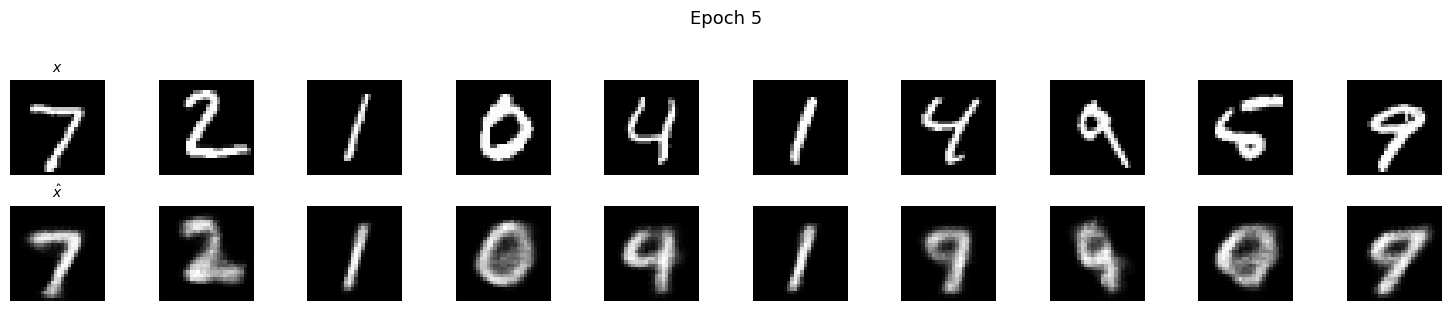

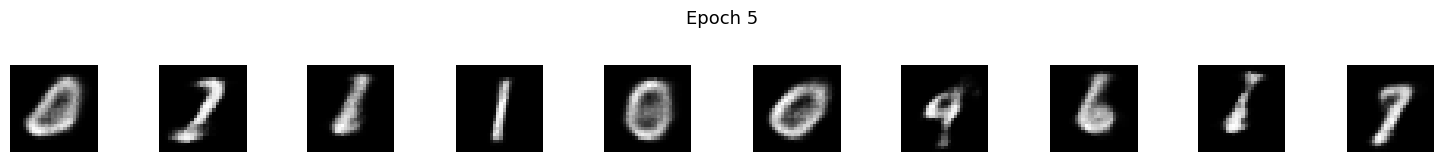

Epoch   6/60 Recon=0.17 D=1.3284 G=0.7553
Epoch   7/60 Recon=0.17 D=1.3428 G=0.7558
Epoch   8/60 Recon=0.18 D=1.3538 G=0.7903
Epoch   9/60 Recon=0.17 D=1.3523 G=0.7311
Epoch  10/60 Recon=0.17 D=1.3503 G=0.7323


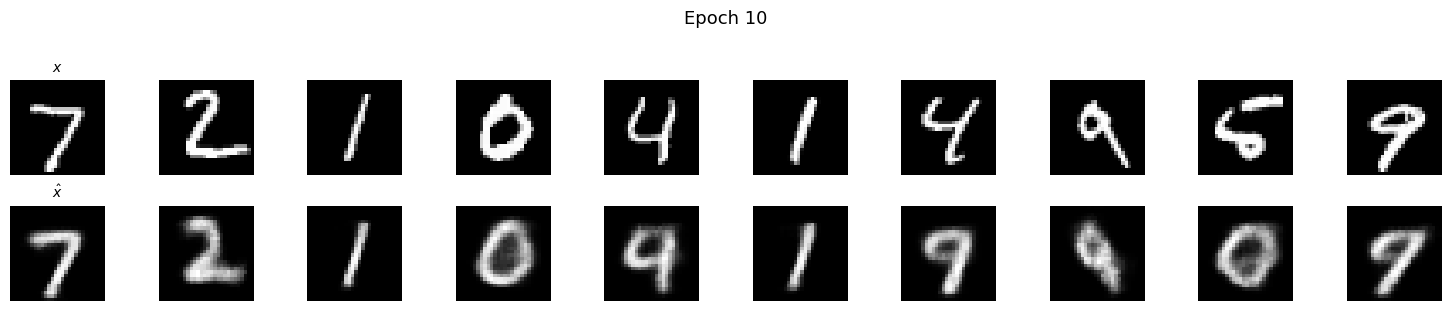

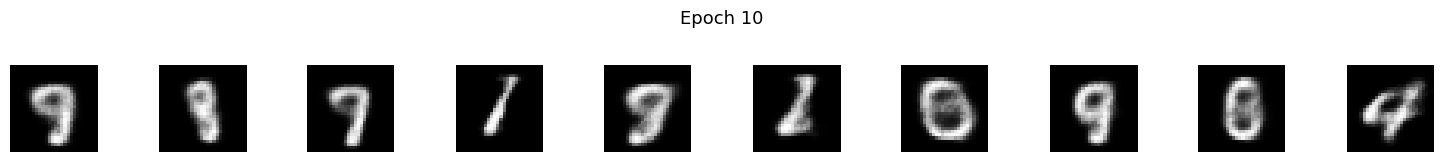

Epoch  11/60 Recon=0.17 D=1.3570 G=0.7325
Epoch  12/60 Recon=0.17 D=1.3686 G=0.7273
Epoch  13/60 Recon=0.17 D=1.3607 G=0.7274
Epoch  14/60 Recon=0.17 D=1.3604 G=0.7258
Epoch  15/60 Recon=0.17 D=1.3682 G=0.7236


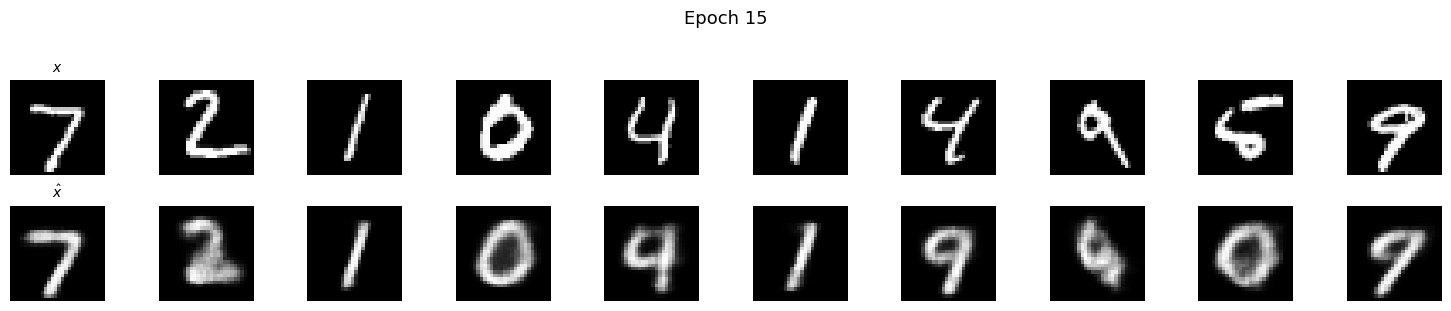

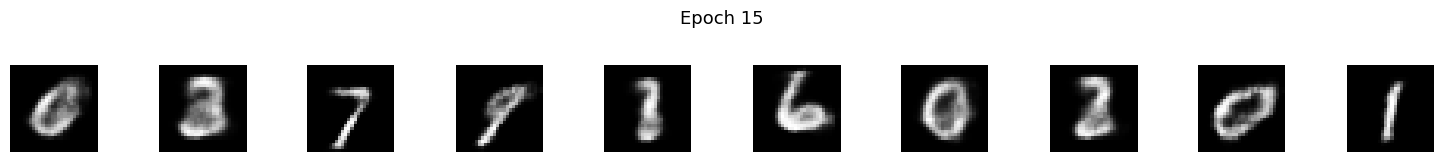

Epoch  16/60 Recon=0.17 D=1.3754 G=0.7153
Epoch  17/60 Recon=0.17 D=1.3771 G=0.7128
Epoch  18/60 Recon=0.17 D=1.3787 G=0.7097
Epoch  19/60 Recon=0.17 D=1.3771 G=0.7094
Epoch  20/60 Recon=0.17 D=1.3773 G=0.7091


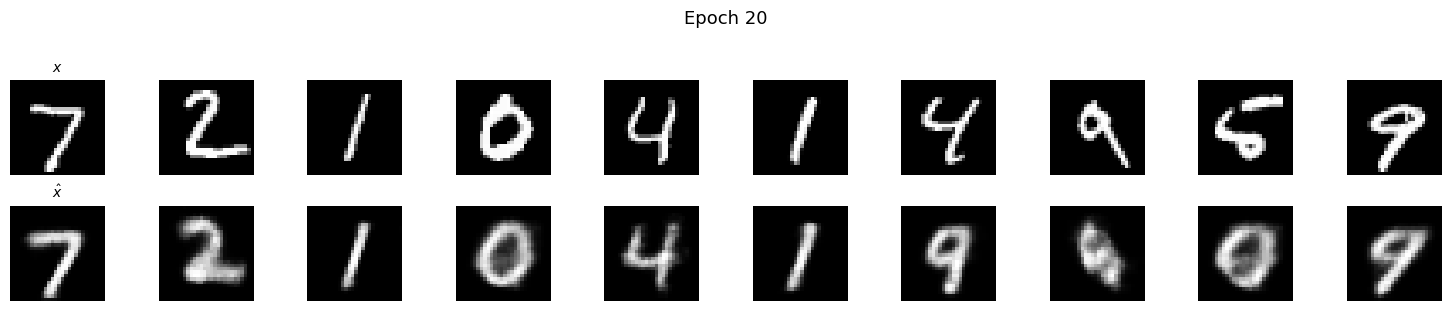

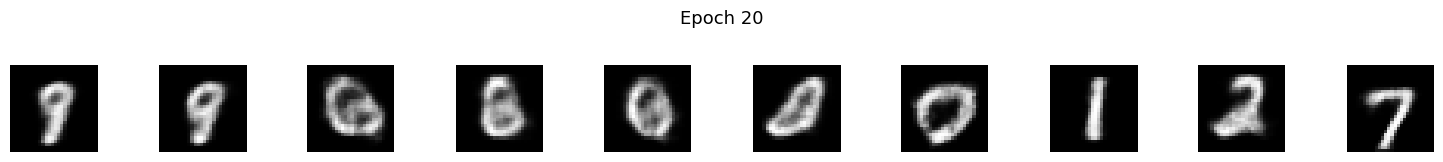

Epoch  21/60 Recon=0.17 D=1.3829 G=0.7048
Epoch  22/60 Recon=0.17 D=1.3827 G=0.7060
Epoch  23/60 Recon=0.17 D=1.3813 G=0.7048
Epoch  24/60 Recon=0.17 D=1.3817 G=0.7059
Epoch  25/60 Recon=0.21 D=1.5336 G=0.7677


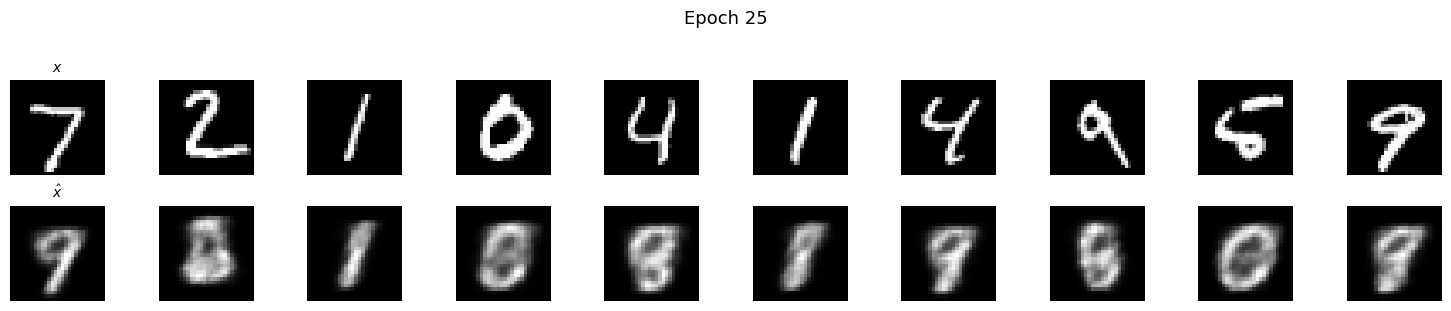

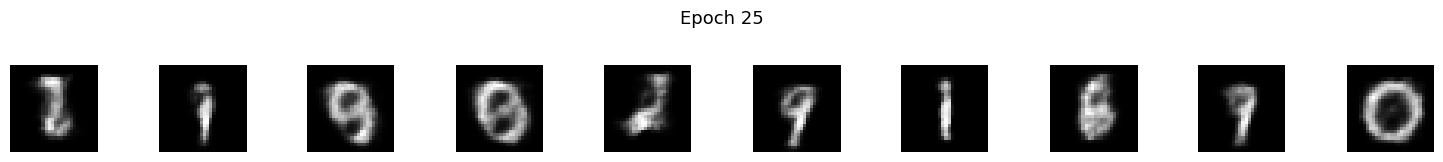

Epoch  26/60 Recon=0.19 D=1.4092 G=0.7208
Epoch  27/60 Recon=0.17 D=1.3612 G=0.7178
Epoch  28/60 Recon=0.17 D=1.3680 G=0.7122
Epoch  29/60 Recon=0.17 D=1.3702 G=0.7119
Epoch  30/60 Recon=0.17 D=1.3730 G=0.7088


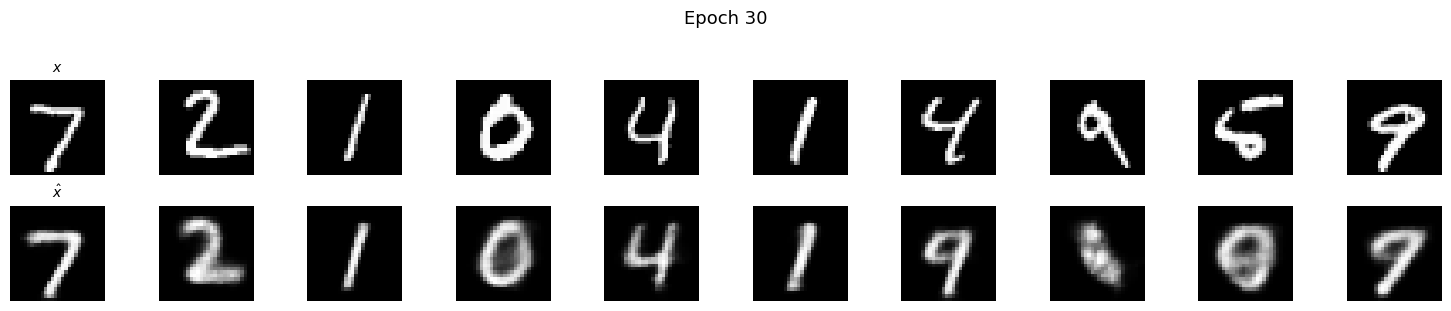

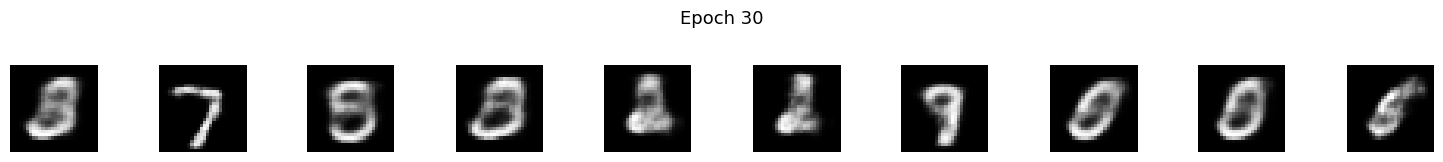

Epoch  31/60 Recon=0.17 D=1.3738 G=0.7084
Epoch  32/60 Recon=0.17 D=1.3770 G=0.7065
Epoch  33/60 Recon=0.17 D=1.3790 G=0.7058
Epoch  34/60 Recon=0.17 D=1.3820 G=0.7040
Epoch  35/60 Recon=0.17 D=1.3812 G=0.7030


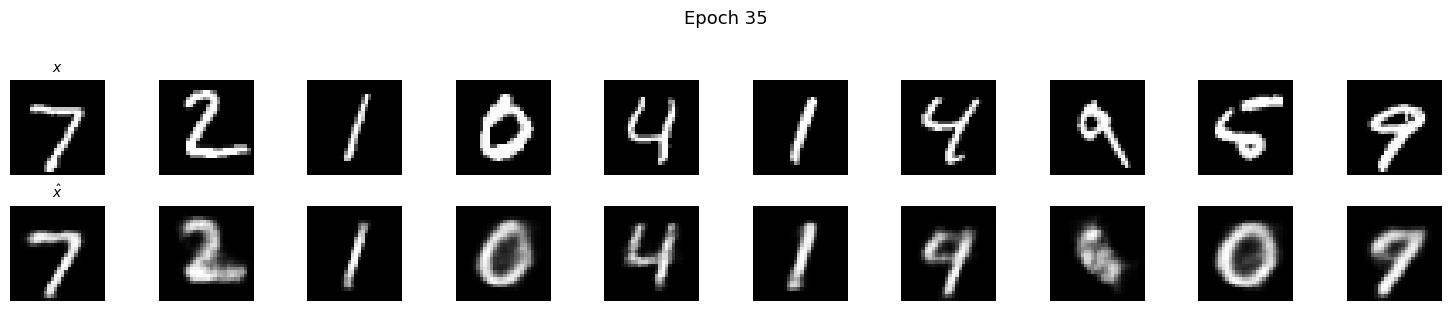

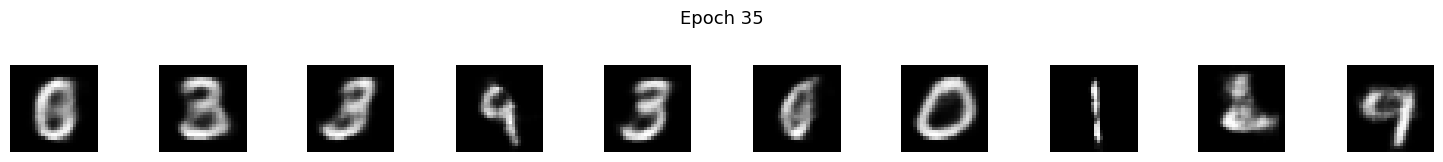

Epoch  36/60 Recon=0.17 D=1.3818 G=0.7037
Epoch  37/60 Recon=0.17 D=1.3785 G=0.7064
Epoch  38/60 Recon=0.17 D=1.3819 G=0.7045
Epoch  39/60 Recon=0.17 D=1.3823 G=0.7040
Epoch  40/60 Recon=0.17 D=1.3820 G=0.7026


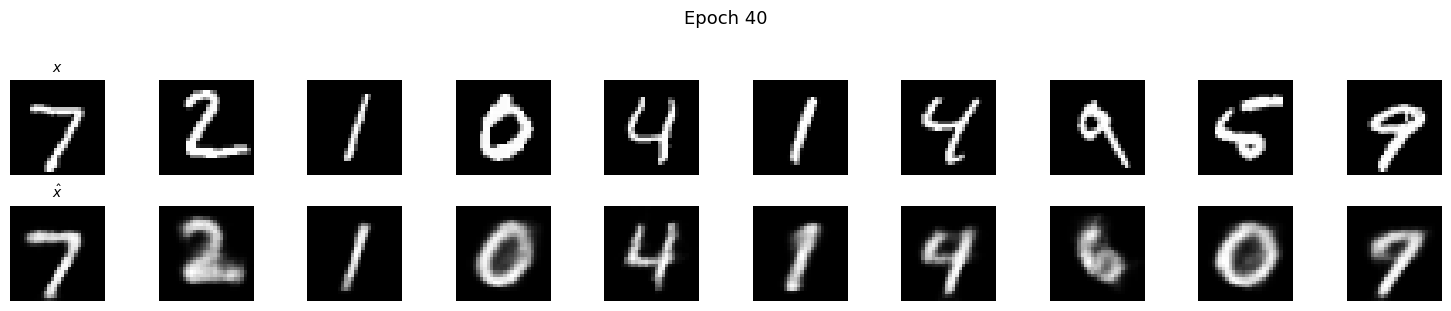

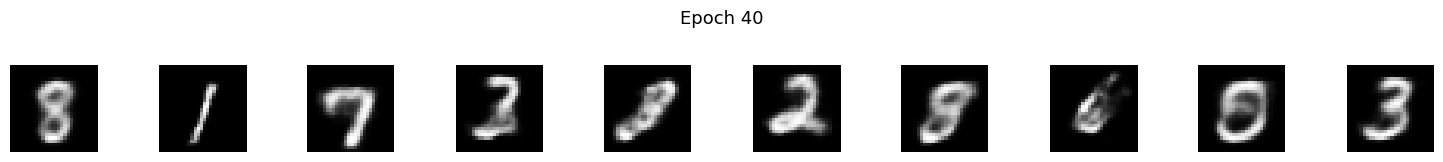

Epoch  41/60 Recon=0.17 D=1.3834 G=0.7025
Epoch  42/60 Recon=0.17 D=1.3903 G=0.7021
Epoch  43/60 Recon=0.18 D=1.4053 G=0.7081
Epoch  44/60 Recon=0.17 D=1.3857 G=0.7029
Epoch  45/60 Recon=0.17 D=1.3842 G=0.7033


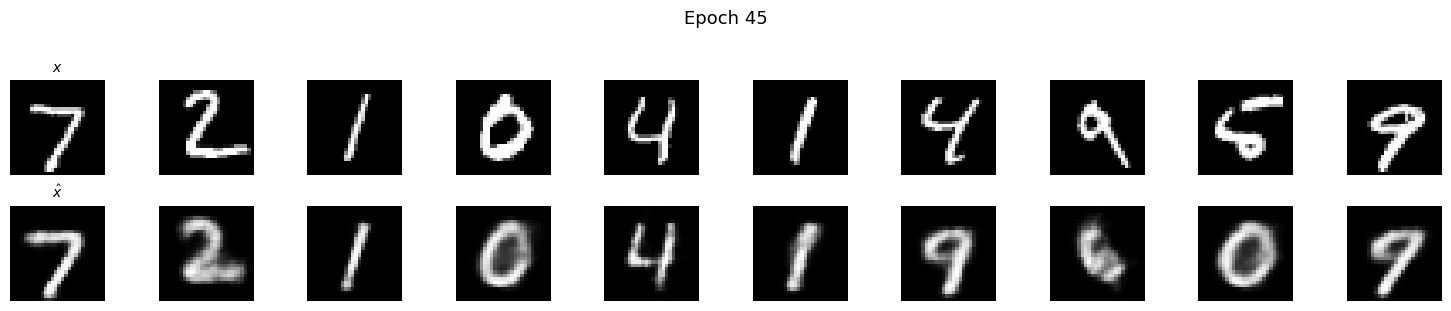

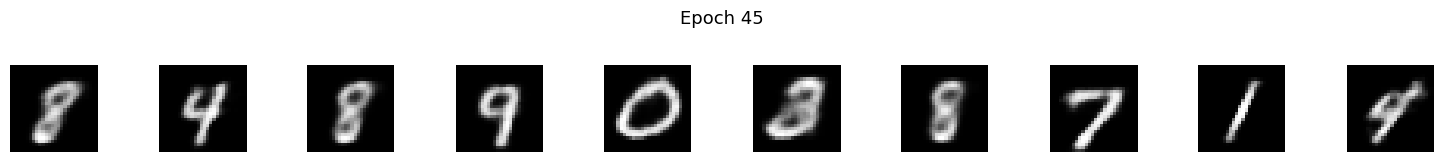

Epoch  46/60 Recon=0.17 D=1.3836 G=0.7021
Epoch  47/60 Recon=0.17 D=1.3872 G=0.7042
Epoch  48/60 Recon=0.17 D=1.3866 G=0.7024
Epoch  49/60 Recon=0.17 D=1.3857 G=0.7018
Epoch  50/60 Recon=0.17 D=1.3853 G=0.7015


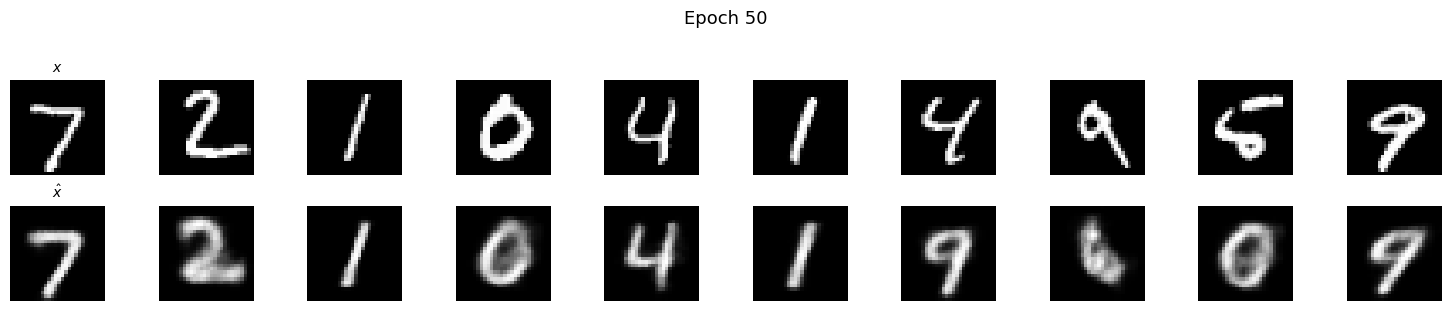

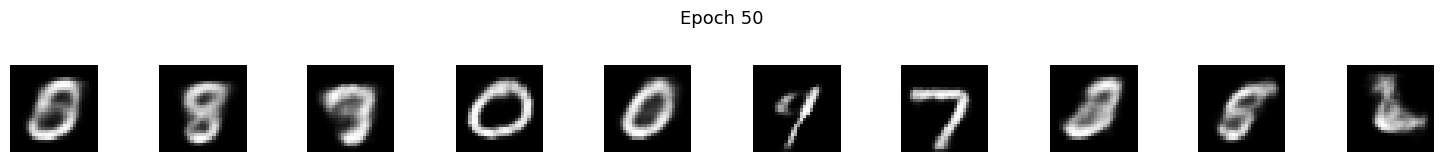

Epoch  51/60 Recon=0.17 D=1.3859 G=0.7022
Epoch  52/60 Recon=0.17 D=1.3875 G=0.7025
Epoch  53/60 Recon=0.17 D=1.3859 G=0.7017
Epoch  54/60 Recon=0.17 D=1.3846 G=0.7017
Epoch  55/60 Recon=0.17 D=1.3844 G=0.7013


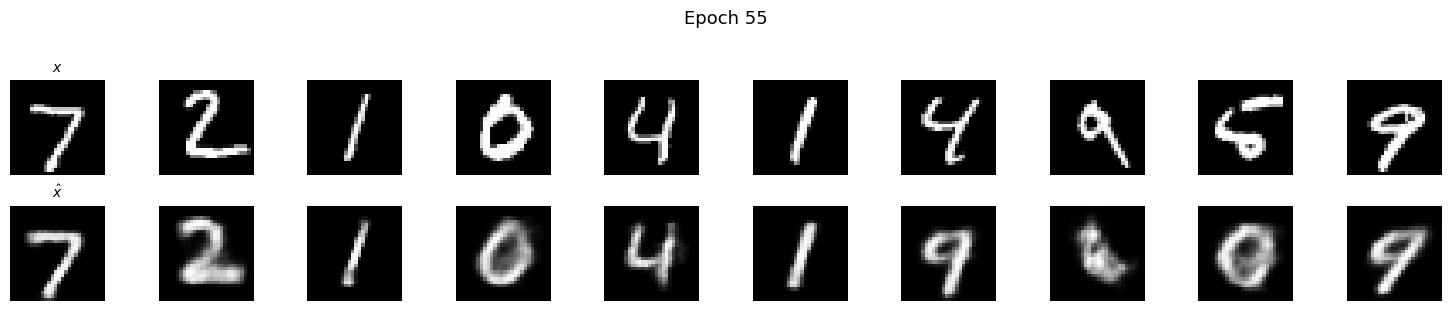

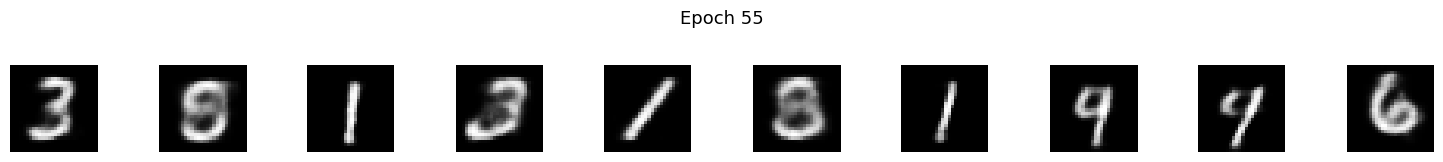

Epoch  56/60 Recon=0.17 D=1.3847 G=0.7013
Epoch  57/60 Recon=0.17 D=1.3856 G=0.7013
Epoch  58/60 Recon=0.17 D=1.3865 G=0.7028
Epoch  59/60 Recon=0.17 D=1.3808 G=0.7012
Epoch  60/60 Recon=0.17 D=1.3844 G=0.7034


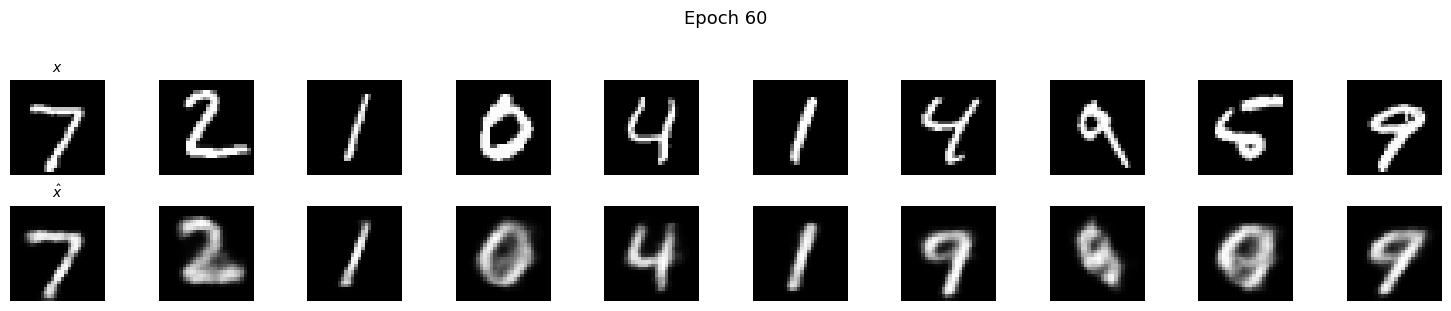

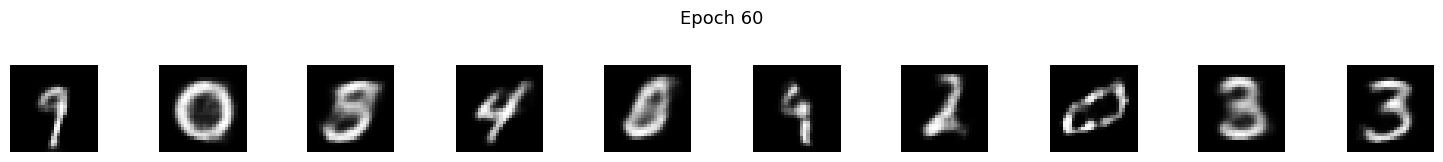

In [12]:
seed_everything(9951)

aae = AdversarialAutoencoder(
    hidden_channels=hidden_channels,
    latent_dim=latent_dim,
).to(device)

history = train_aae(aae, train_loader, epochs=epochs, lr=lr, lr_reg=lr_reg)

### 4. Evaluation

Evaluates the trained model on the hidden test set. **Do not alter this section.**

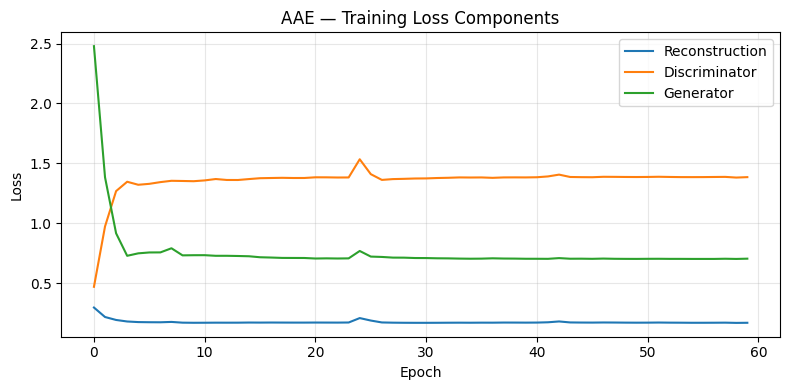

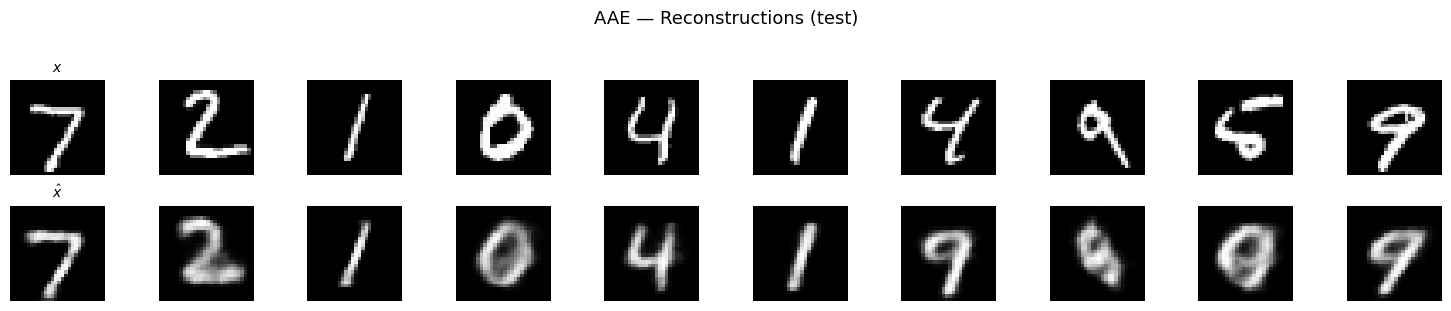

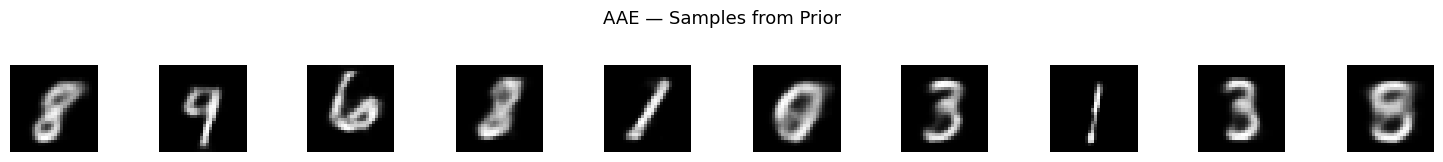

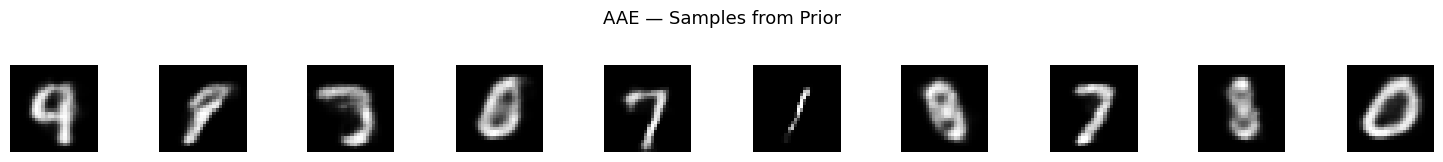

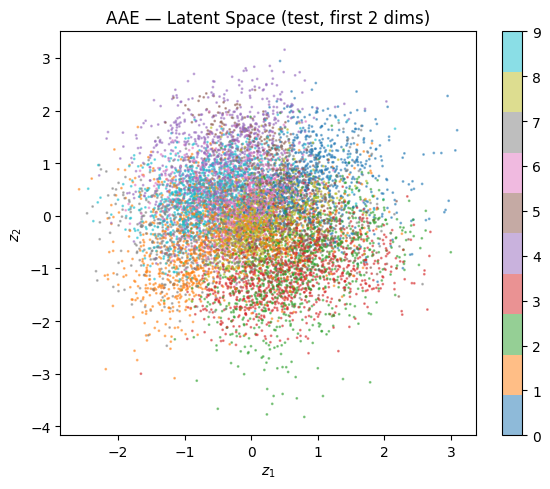

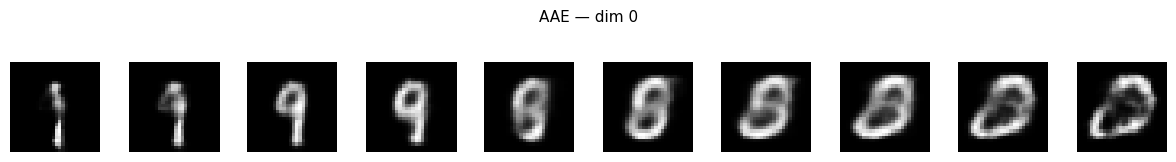

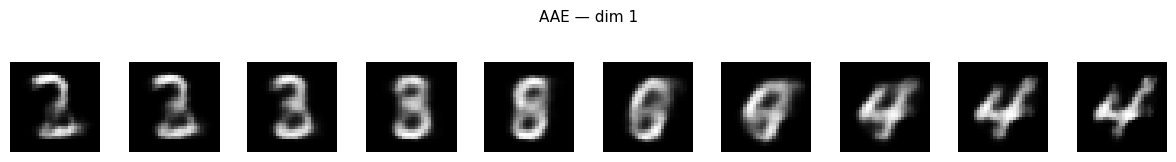

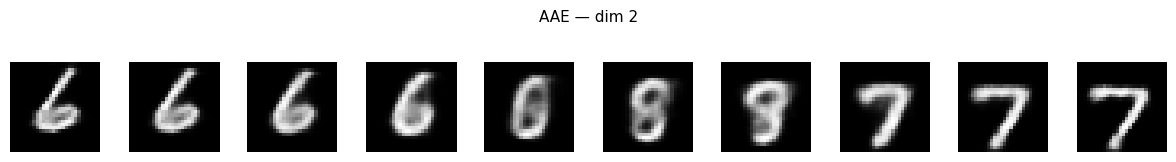

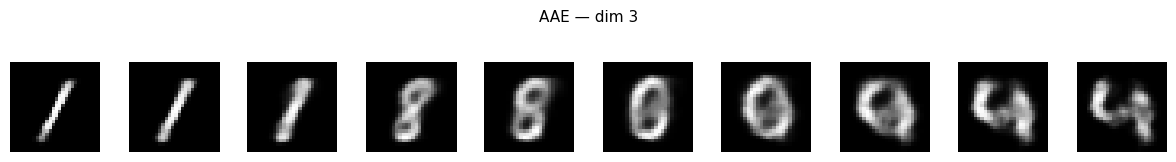

Discriminator accuracy (real vs. fake): 0.5125  (ideal ≈ 0.50)


0.5125

In [13]:
plot_losses(history, "AAE — Training Loss Components")
show_reconstructions(aae, test_loader, title="AAE — Reconstructions (test)")
show_samples(aae, n=10, title="AAE — Samples from Prior")
show_samples(aae, n=10, title="AAE — Samples from Prior")
show_latent_space(aae, test_loader, title="AAE — Latent Space (test, first 2 dims)")
for dim in range(latent_dim):
    show_latent_traversal(aae, dim_to_traverse=dim, title="AAE")
discriminator_accuracy(aae, test_loader)

## Notes on the experimentation (hyperparams tuning)

I first ran the Synthetic dataset with the default hyperparameters (lr = lr_reg = 1e-3, 25 epochs) and in that case the training was stable: L_D landed around 1.37, L_G around 0.71, and the discriminator accuracy stayed near 0.56.

Then I also tried Small-MNIST and MNIST with the suggested hyperparameters (lr = 1e-3, lr_reg = 1e-4, 30 epochs), but both runs collapsed. On full MNIST the discriminator reached 0.95 accuracy, L_D dropped to 0.23, L_G blew up to 8.65.

Before trying to change and improve the code I saw that the main difference was the ratio between lr and lr_reg: 1:1 on Synthetic, 10:1 on MNIST. With lr_reg ten times smaller than lr, the discriminator was trained relatively faster than the encoder at every step, so it pulled ahead early and the encoder never caught up.

I retried MNIST with lr = lr_reg = 5e-4, 60 epochs, latent_dim = 4. It converged in about 5 epochs and then stayed stable for the remaining 55, with much better results than before: L_D ≈ 1.38, L_G ≈ 0.70, disc accuracy 0.51.

I applied the same fix to Small-MNIST (lr = lr_reg = 5e-4, 60 epochs, latent_dim = 2) and it also works: L_D ≈ 1.37, L_G ≈ 0.73, disc accuracy 0.56. The training is a bit noisier than on full MNIST, with some occasional dips around epochs 9, 19, 25, 40, but it always recovers and the final equilibrium is reasonable.